# 2. Análisis exploratorio de datos

La segunda pestaña del dashboard es un análisis exploratorio con filtros. Todo el análisis usa únicamente el
conjunto de entrenamiento, 44.903 adultos, y se recalcula cada vez que se cambia algún filtro del panel
lateral (año, sexo, edad, raza o etnia y antecedente de ACV). En este capítulo las gráficas aparecen con los filtros en su
valor inicial. Cuando una lectura cambia mucho al filtrar, damos el ejemplo.

Una advertencia que se repite en varias secciones: con más de 40.000 adultos casi cualquier diferencia
resulta estadísticamente significativa. Por eso el análisis se apoya en tamaños de efecto (V de Cramér,
razones de odds, diferencias de prevalencia con su intervalo) y no en los valores p.

In [1]:
from informe import *
from scipy import stats

df = DF
y = df[OBJETIVO]
k = F.kpis_eda(df)
print(f"Adultos: {k['n']:,} | casos: {k['casos']:,} | prevalencia: {k['prev']:.2%} (IC 95 %: {k['lo']:.2%}-{k['hi']:.2%})")
print(f"Edad mediana: {k['edad']:.0f} | mujeres: {k['mujeres']:.1%} | 65 años o más: {k['mayores']:.1%}")

Adultos: 44,903 | casos: 9,253 | prevalencia: 20.61% (IC 95 %: 20.24%-20.98%)
Edad mediana: 54 | mujeres: 54.5% | 65 años o más: 31.8%


Las tarjetas que encabezan la pestaña resumen la población que queda con los filtros: cuántos adultos
hay, cuántos reportan dificultad, la prevalencia con su intervalo de confianza de Wilson, la edad mediana
y la proporción de mujeres. Sin filtros son 44.903 adultos, 9.253 con dificultad (20,6 %, IC 95 %: 20,2 %-21,0 %),
mediana de 54 años y un 54 % de mujeres. Con los filtros se aprecia lo rápido que cambia el panorama:
al elegir solo hombres con antecedente de ACV quedan 678 adultos, la mediana de edad sube a 70 años y la
prevalencia llega al 42,8 % (IC 95 %: 39,1 %-46,5 %). El intervalo se ensancha porque la muestra es mucho más pequeña,
y esa es la razón por la que el dashboard dibuja siempre las barras de error.

## 2.1 Variable objetivo

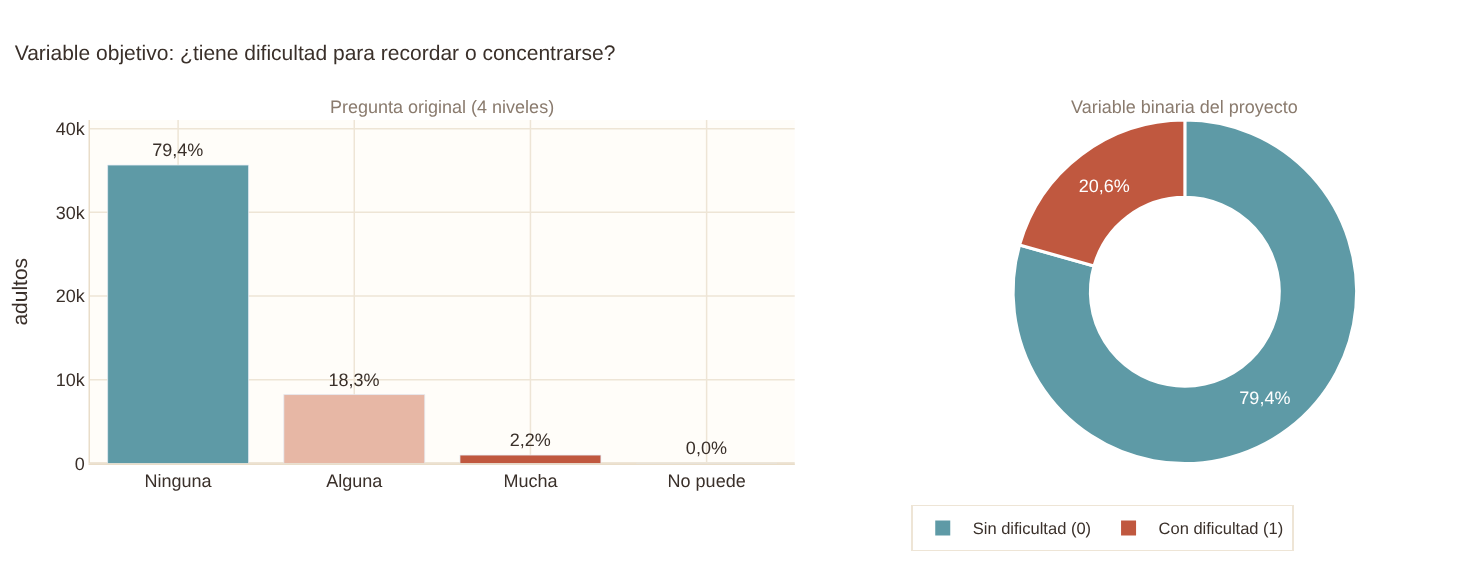

nivel_dificultad_cognitiva
Ninguna     35650
Alguna       8236
Mucha        1002
No puede       15


In [2]:
mostrar(F.fig_niveles(df))
print(df["nivel_dificultad_cognitiva"].value_counts().to_string())

La pregunta original de la NHIS tiene cuatro niveles: ninguna dificultad, alguna, mucha o no puede. Casi
todos los casos están en el segundo nivel. El 79,4 % de los adultos no reporta dificultad, el 18,3 % reporta alguna,
el 2,2 % mucha y apenas 15 personas, el 0,03 %, dicen que no pueden recordar o concentrarse. Con tan
pocos casos en los niveles altos, modelarlos por separado no sería viable, y por eso los reunimos en una variable binaria: 0 si
no hay dificultad y 1 si hay alguna, mucha o no puede. La dona de la derecha muestra el resultado, 20,6 % de
positivos frente a 79,4 % de negativos, es decir, un desbalance de 3,85 a 1.

Ese desbalance no es extremo pero tiene consecuencias prácticas. Un modelo que siempre responda «sin
dificultad» acertaría el 79,4 % de las veces y no detectaría ningún caso, de modo que el accuracy
no sirve para juzgar los modelos. De ahí que usemos la PR-AUC como métrica principal y que las particiones
sean estratificadas.

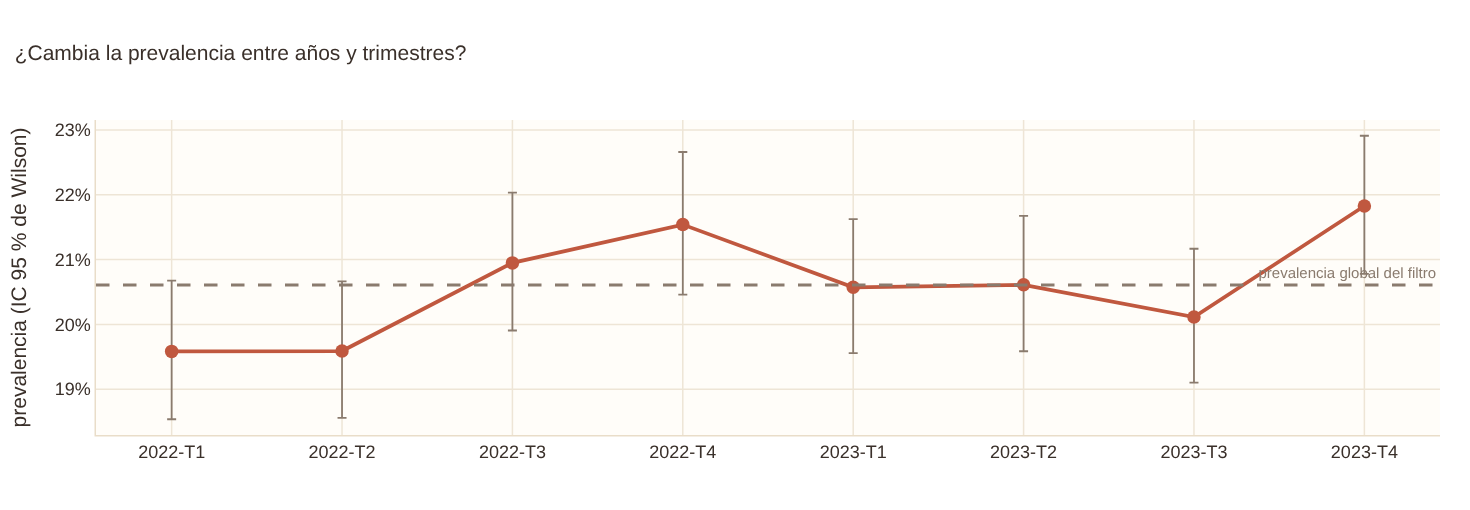

año: chi2 = 0.86, p = 0.354, V de Cramér = 0.000
trimestre (8 periodos): chi2 = 16.21, p = 0.023, V de Cramér = 0.014


In [3]:
mostrar(F.fig_trimestre(df))
d = df.assign(periodo=df["anio"].astype(str) + "-T" + df["trimestre"].astype(str))
ct_anio, ct_trim = pd.crosstab(df["anio"], y), pd.crosstab(d["periodo"], y)
for nombre, t in [("año", ct_anio), ("trimestre (8 periodos)", ct_trim)]:
    chi2, p, _, _ = stats.chi2_contingency(t)
    from dcs.utils import cramers_v
    print(f"{nombre}: chi2 = {chi2:.2f}, p = {p:.3f}, V de Cramér = {cramers_v(t.values):.3f}")

La segunda gráfica pregunta si el fenómeno cambia con el tiempo. La prevalencia es del 20,4 % en 2022 y del
20,8 % en 2023, una diferencia sin significación (p = 0,35). Por trimestres hay variaciones que van del 19,6 % en el primer
trimestre de 2022 al 21,8 % en el último de 2023. La prueba chi-cuadrado sí da un valor p
pequeño (0,023), pero el tamaño del efecto es despreciable (V de Cramér = 0,014) y los intervalos de
confianza se solapan con la línea de la prevalencia global casi en todos los periodos; no hay una
tendencia sino una oscilación dentro del ruido esperado. La conclusión práctica es que podemos
combinar los dos años y que no hace falta una validación cronológica. El filtro de año del dashboard permite
comprobarlo: al dejar solo 2022 o solo 2023 las demás gráficas cambian muy poco.

## 2.2 Edad

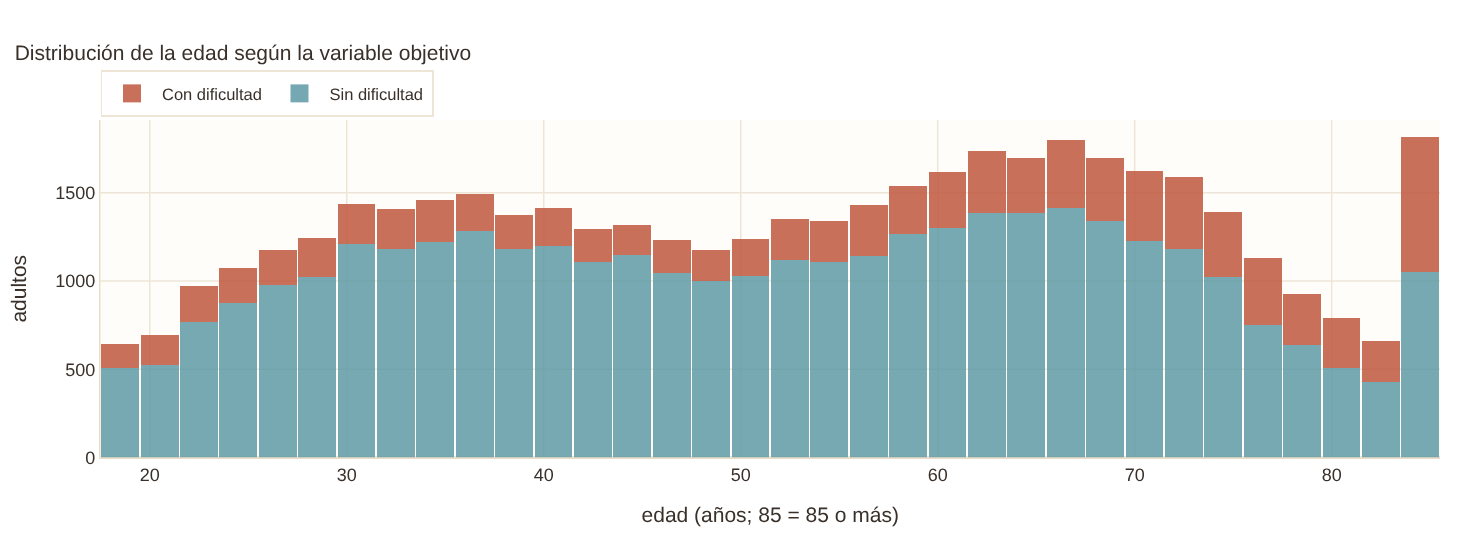

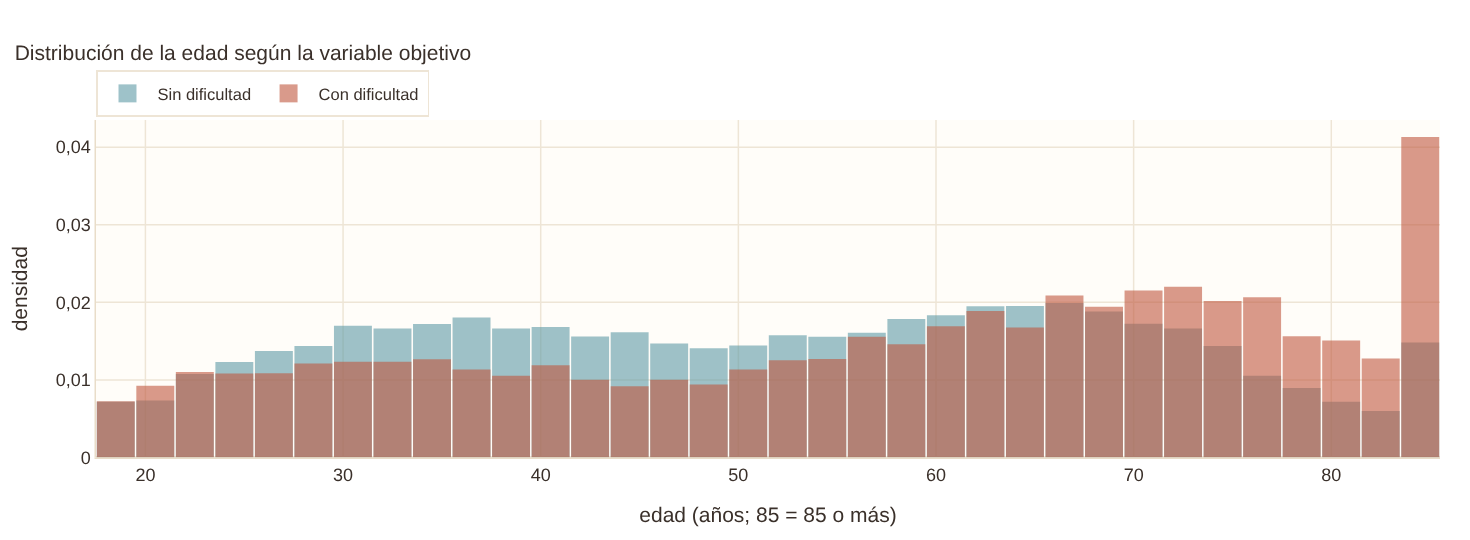

count    44797.00
mean        52.86
std         18.40
min         18.00
25%         37.00
50%         54.00
75%         68.00
max         85.00
Adultos con edad truncada en 85: 1525


In [4]:
mostrar(F.fig_hist_edad(df, "conteo"))
mostrar(F.fig_hist_edad(df, "densidad"))
print(df["edad"].describe().round(2).to_string())
print("Adultos con edad truncada en 85:", (df["edad"] == 85).sum())

El histograma apilado muestra cuántos adultos hay en cada edad y, dentro de cada barra, cuántos reportan
dificultad. La edad media es 52,9 años (mediana 54), con una distribución casi plana entre los 25 y los 80
años. El pico del extremo derecho es un artefacto: el CDC trunca la edad en 85 años para proteger la
confidencialidad, así que ese valor significa en realidad «85 o más» y reúne a 1.525 adultos (3,4 %).

La vista de densidad por clase, que se activa con el selector de la parte superior, permite comparar la forma de las dos
distribuciones sin que influya el tamaño de cada grupo. Los adultos con dificultad (rojo) acumulan más peso en las
edades altas, pero también hay una pequeña elevación en los 20 años: la edad no se comporta de forma
simple, y la siguiente gráfica lo muestra con claridad.

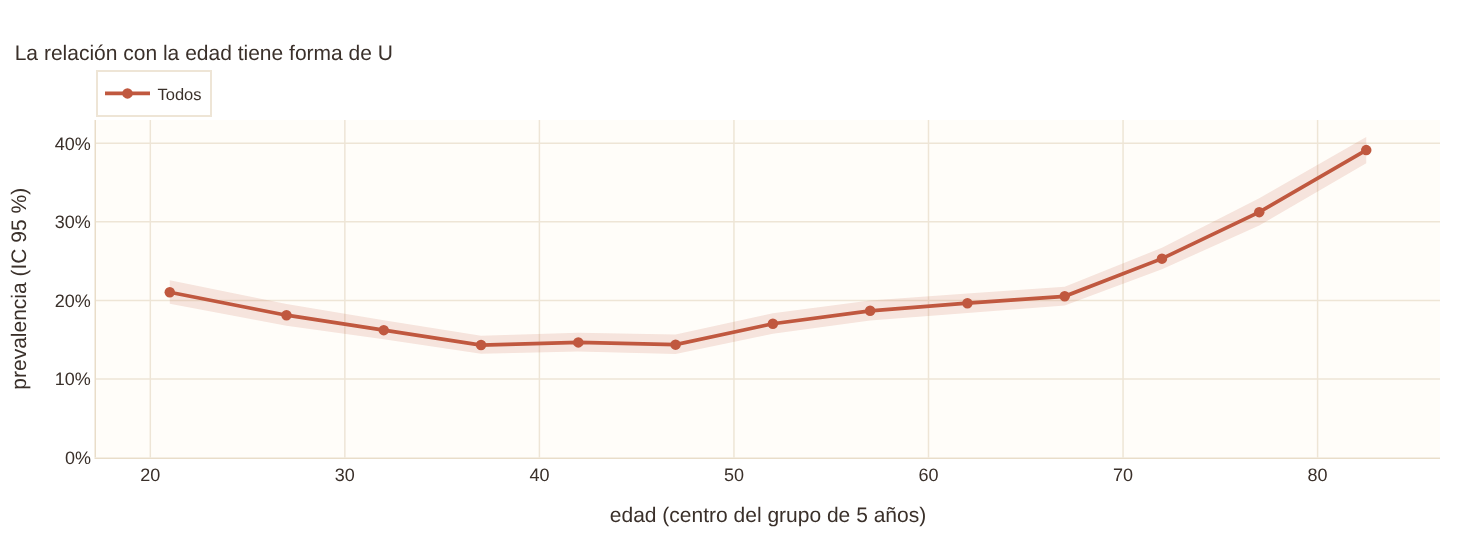

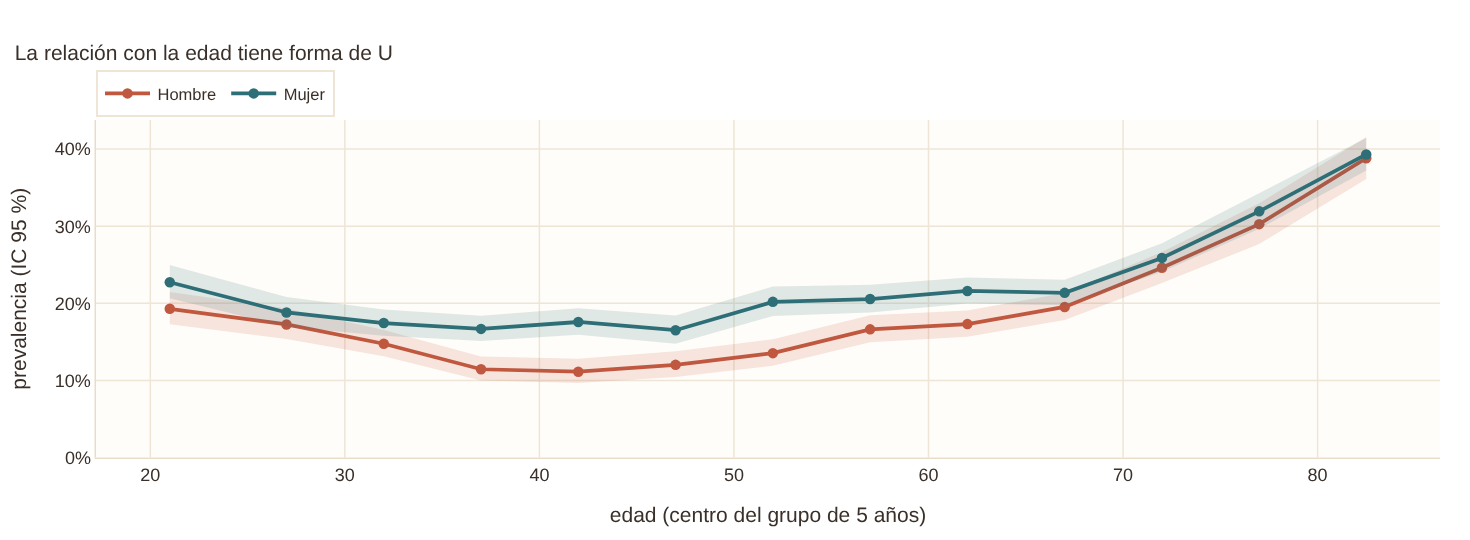

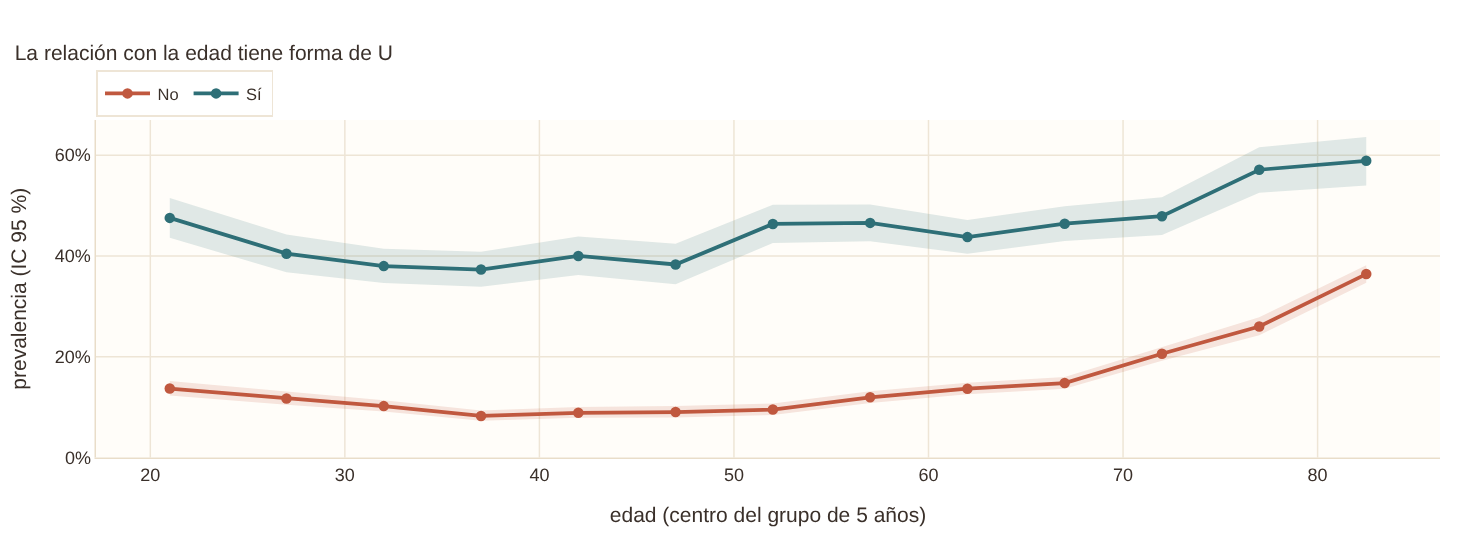

grupo de edad,n,prevalencia,IC inf.,IC sup.
18-24,"2,824",21.0%,19.6%,22.6%
25-29,"2,982",18.1%,16.8%,19.5%
30-34,"3,590",16.2%,15.0%,17.5%
35-39,"3,585",14.3%,13.2%,15.5%
40-44,"3,392",14.7%,13.5%,15.9%
45-49,"3,042",14.4%,13.2%,15.7%
50-54,"3,231",17.0%,15.8%,18.4%
55-59,"3,668",18.7%,17.4%,20.0%
60-64,"4,207",19.6%,18.5%,20.9%
65-69,"4,342",20.5%,19.3%,21.7%


In [5]:
mostrar(F.fig_prev_edad(df))
mostrar(F.fig_prev_edad(df, "sexo"))
mostrar(F.fig_prev_edad(df.dropna(subset=["depresion_dx"]), "depresion_dx"))
tabla = prevalencia_por(df, "grupo_edad_q", F.GRUPO_EDAD_LBL)[["grupo_edad_q", "n", "prevalencia", "ic_inf", "ic_sup"]]
ver(tabla.rename(columns={"grupo_edad_q": "grupo de edad", "ic_inf": "IC inf.", "ic_sup": "IC sup."}),
    {"n": "{:,.0f}", "prevalencia": "{:.1%}", "IC inf.": "{:.1%}", "IC sup.": "{:.1%}"})

Esta es probablemente la gráfica más importante de la pestaña. La prevalencia no crece con la edad en línea
recta, sino que tiene forma de U: es del 21,0 % entre los 18 y los 24 años, baja hasta un mínimo cercano
al 14 % entre los 35 y los 49, y desde ahí sube de manera sostenida hasta el 39,1 % en los adultos de 80 a 85. La
dificultad de los adultos jóvenes probablemente obedece a razones distintas del envejecimiento cerebral, como la atención, el
sueño o la ansiedad, mientras que la de los mayores se asocia más con el deterioro propio de la edad. Un
término lineal de edad no puede representar una U, y por eso el modelo usa splines cúbicos.

El selector «Desagregar» muestra que la forma se mantiene entre subgrupos. Por sexo, las mujeres
tienen una prevalencia más alta en casi todas las edades (22,4 % frente a 18,4 % en total), aunque la diferencia se
vuelve pequeña después de los 70. Al separar por diagnóstico de depresión, las dos curvas son
paralelas y la de quienes tienen depresión queda muy por encima: la depresión añade riesgo en todas las edades.
Además, el efecto es más visible en los jóvenes y los adultos de mediana edad, donde la distancia entre las curvas es
mayor.

Las bandas sombreadas son el intervalo de confianza del 95 %. Cuando un subgrupo tiene menos de 30
adultos en un grupo de edad, el dashboard omite ese punto para no mostrar prevalencias inestables.

## 2.3 Factores de riesgo

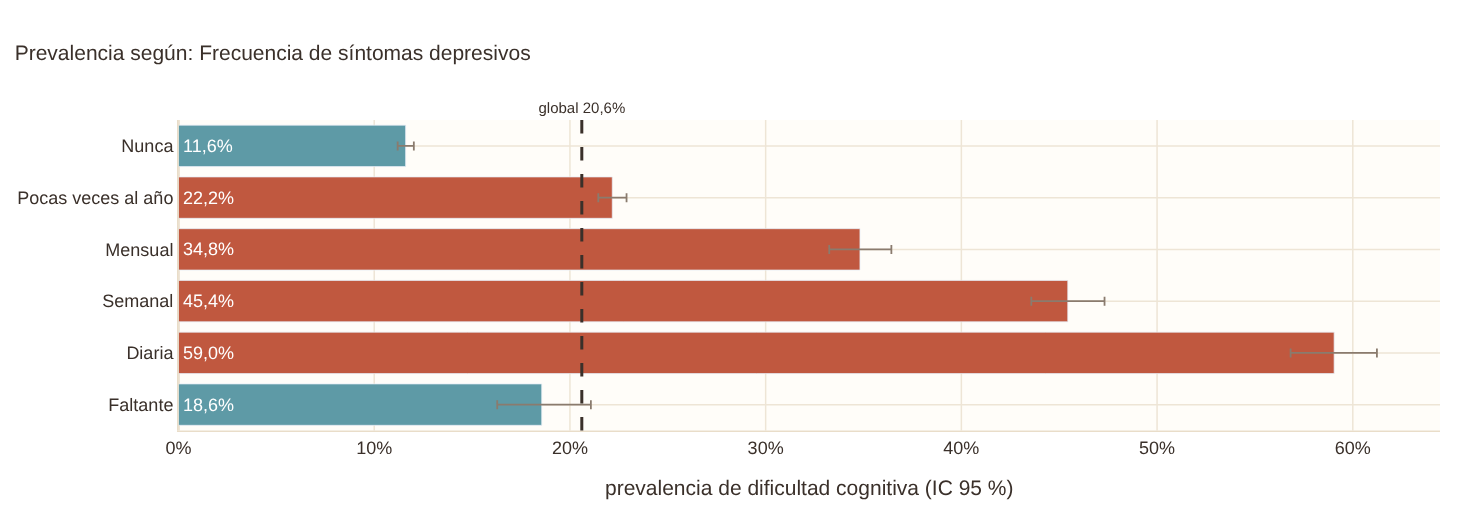

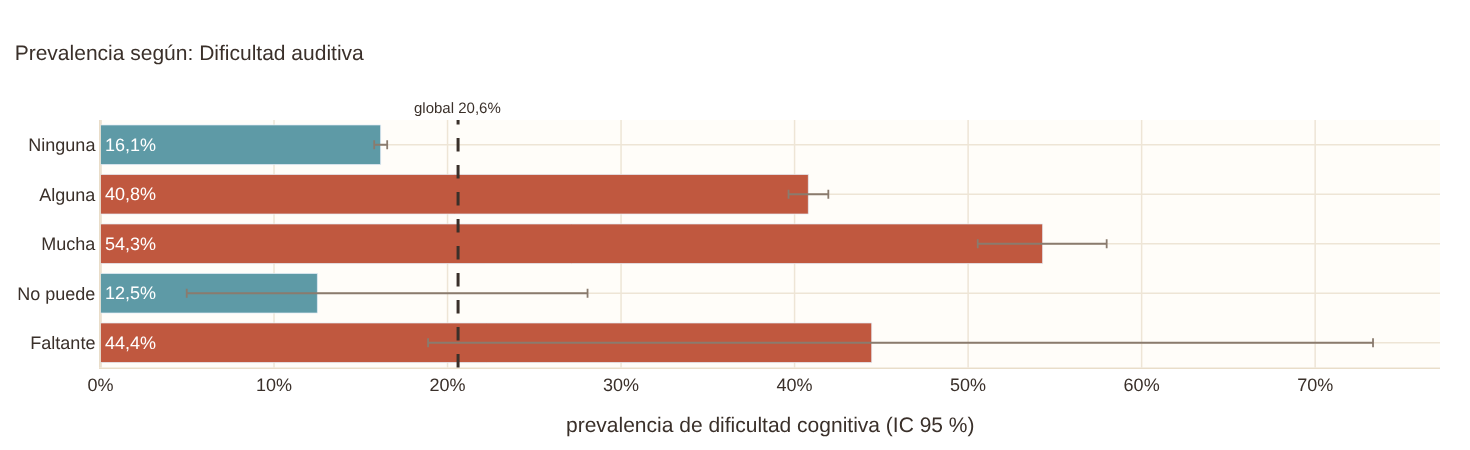

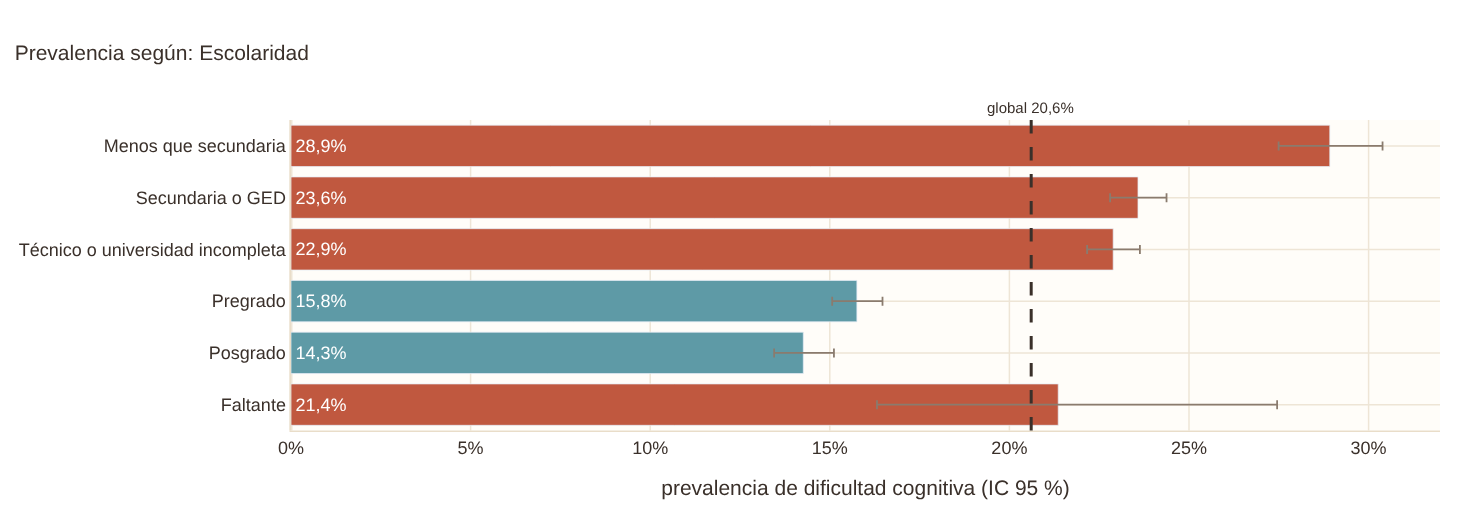

In [6]:
for var in ["frecuencia_depresion", "dificultad_auditiva", "educacion"]:
    mostrar(F.fig_prev_categoria(df, var))

Cada barra es la prevalencia de dificultad cognitiva dentro de una categoría, con su intervalo de
confianza, y la línea punteada es la prevalencia global. Las barras rojas superan el promedio y las azules quedan por debajo. En el
dashboard se puede elegir cualquiera de las 13 predictoras categóricas; aquí mostramos tres, que ilustran los tres
patrones que se repiten.

La frecuencia de síntomas depresivos muestra el gradiente más claro, un patrón de dosis-respuesta: la prevalencia
pasa del 11,6 % en quienes nunca se sienten deprimidos al 22,2 % si les ocurre pocas veces al año, 34,8 % mensualmente, 45,4 % semanalmente y
59,0 % todos los días. En cada escalón la prevalencia aumenta, y el último multiplica por cinco la del primero. La dificultad auditiva sigue el mismo
patrón con menos escalones, de 16,1 % sin dificultad a 40,8 % con alguna; la visual es parecida (16,2 % y 38,3 %). La
escolaridad es el ejemplo de un factor protector: la prevalencia baja de 28,9 % en quienes no terminaron la secundaria
a 14,3 % en quienes tienen posgrado, un descenso casi continuo que concuerda con la hipótesis de la reserva cognitiva.

Si se elige una variable con categorías raras, como la audición, el dashboard muestra también la categoría «No
puede», que tiene apenas 0,07 % de los adultos y un intervalo enorme. Esa categoría rompe el gradiente por
falta de casos, no por un fenómeno real, y es la razón por la que en el preprocesamiento se agrupa con «Mucha».

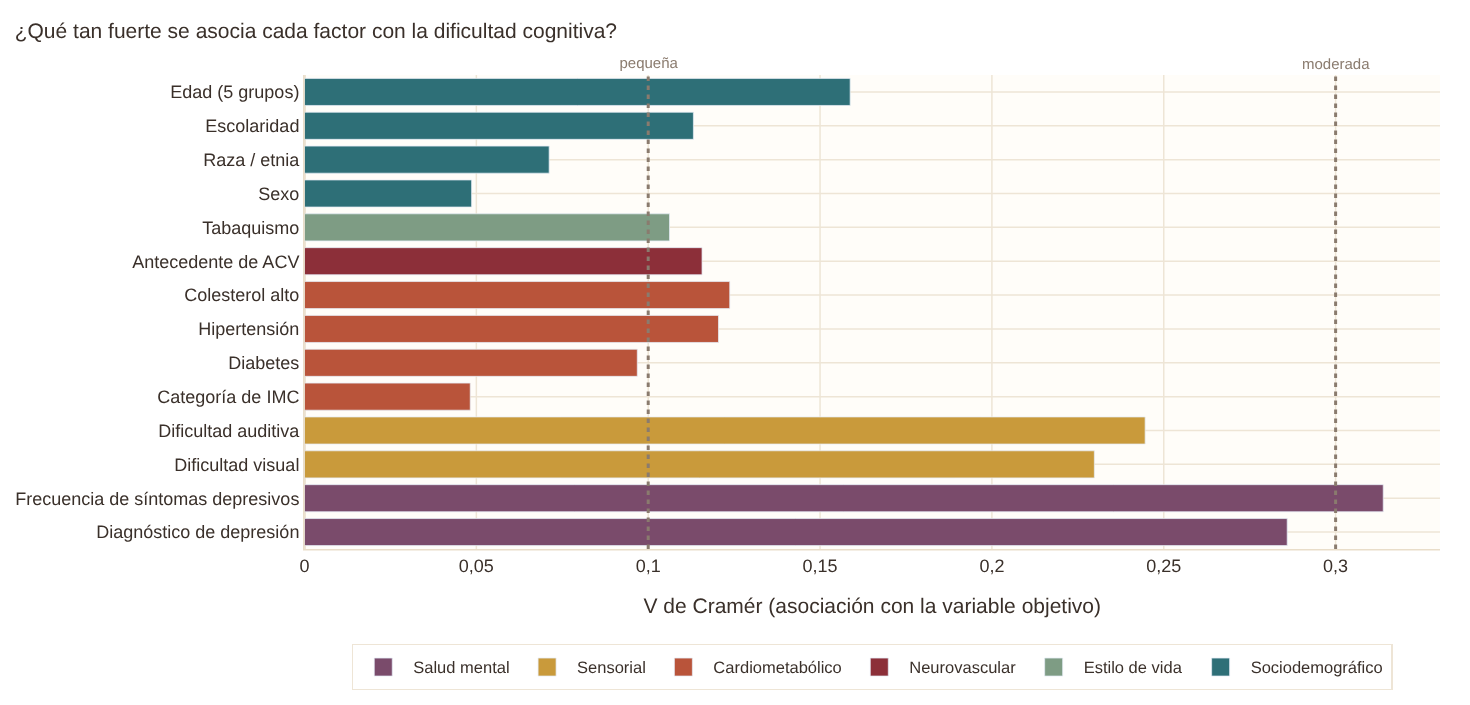

factor,V de Cramér
Frecuencia de síntomas depresivos,0.314
Diagnóstico de depresión,0.286
Dificultad auditiva,0.245
Dificultad visual,0.230
Edad,0.159
Colesterol alto,0.124
Hipertensión,0.120
Antecedente de ACV,0.116
Escolaridad,0.113
Tabaquismo,0.106


In [7]:
mostrar(F.fig_cramer(df))
ver(F.tabla_cramer(df).assign(etiqueta=lambda t: t["variable"].map(ETIQUETAS)).sort_values("V", ascending=False)[["etiqueta", "V"]]
    .rename(columns={"etiqueta": "factor", "V": "V de Cramér"}), {"V de Cramér": "{:.3f}"})

La V de Cramér resume cuánta asociación hay entre cada factor y la variable objetivo, en una escala de 0 a 1. Se
leen los valores de 0,1 como una asociación pequeña y de 0,3 como moderada. La salud mental encabeza la lista con
la frecuencia de síntomas depresivos (V = 0,31) y el diagnóstico de depresión (0,29), le siguen las pérdidas sensoriales
(audición 0,25 y visión 0,23) y después la edad (0,16, calculada con cinco grupos). Los factores vasculares y de estilo de vida
quedan en un nivel pequeño, entre 0,10 y 0,12: colesterol (0,12), hipertensión (0,12), ACV (0,12), escolaridad (0,11) y
tabaquismo (0,11). Con menos de 0,10 están diabetes (0,10), raza o etnia (0,07), sexo (0,05) e IMC (0,05).

Las asociaciones son todas en la dirección que predice la literatura, lo que respalda la validez de la variable
objetivo. También muestra algo importante para lo que viene: ningún factor por sí solo es
decisivo. Los efectos son moderados y el modelo tendrá que combinar muchas señales débiles.

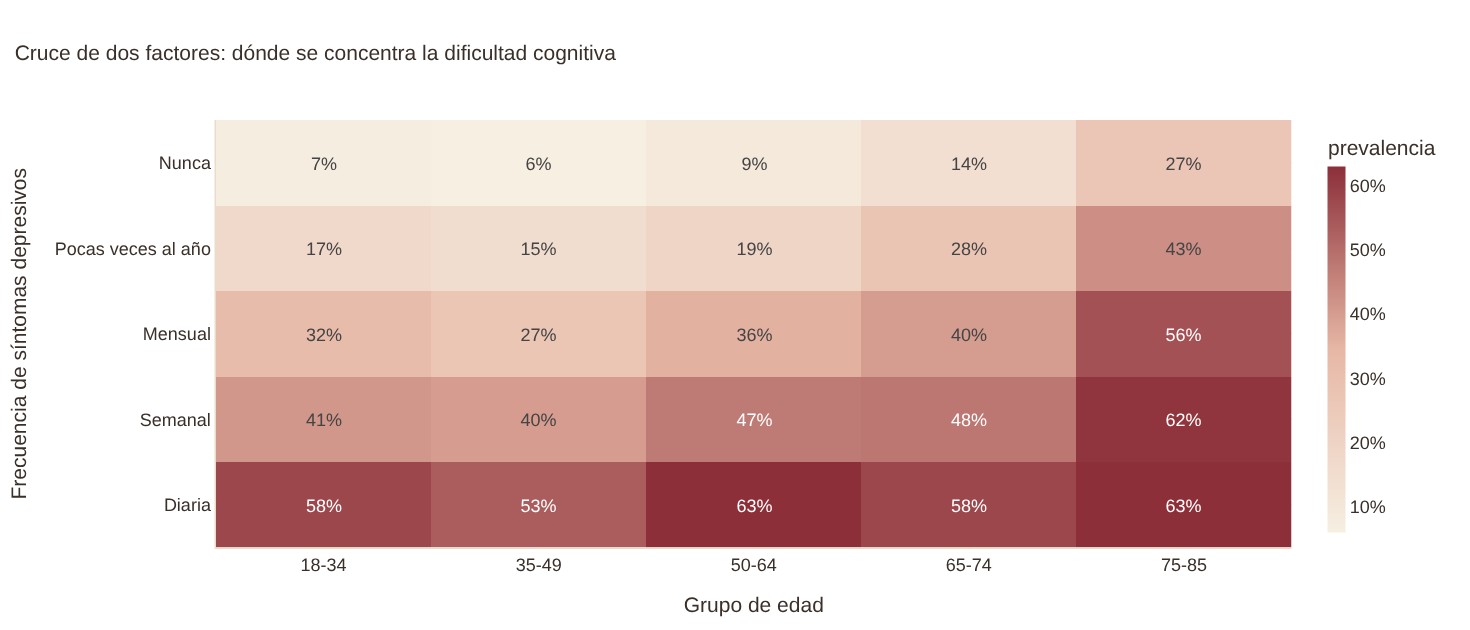

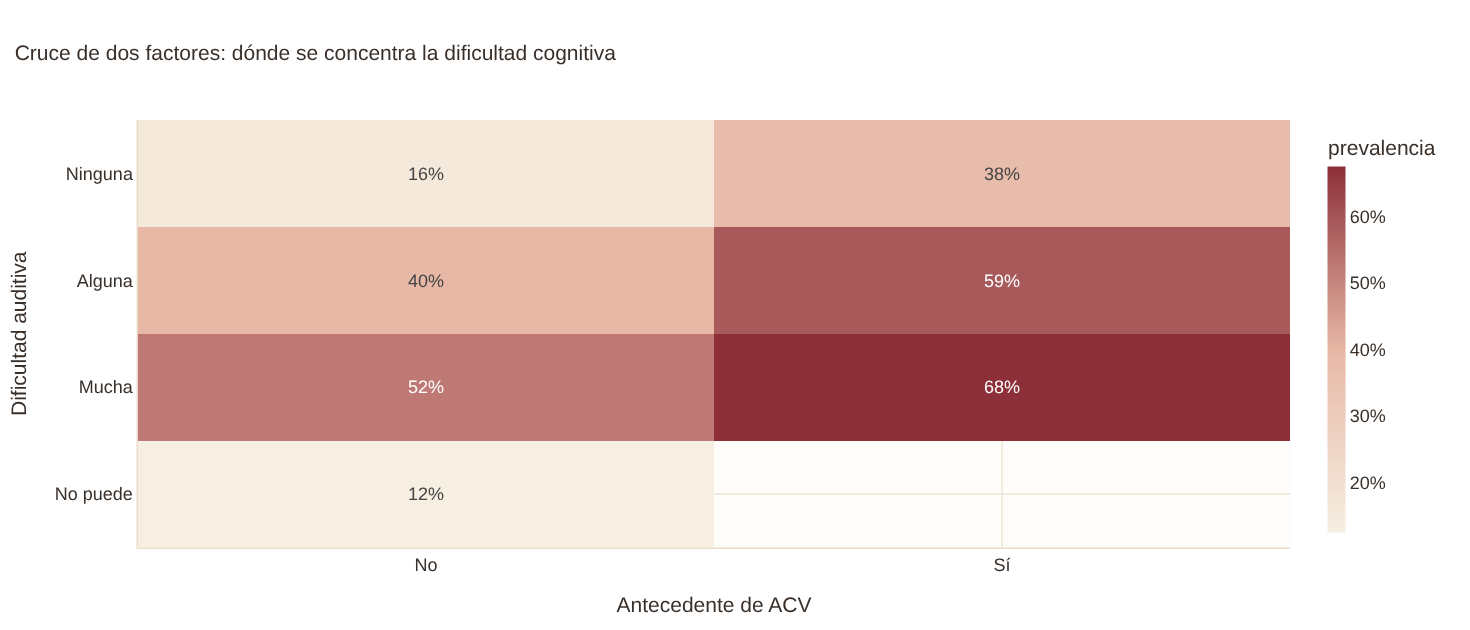

In [8]:
mostrar(F.fig_heatmap_dos(df, "grupo_edad_amplio", "frecuencia_depresion"))
mostrar(F.fig_heatmap_dos(df, "acv", "dificultad_auditiva"))

El mapa de calor cruza dos factores a la vez, y cada celda es la prevalencia de ese cruce. Con la edad en el eje
horizontal y los síntomas depresivos en el vertical, se pueden leer dos efectos a la vez. Hacia abajo, a mayor frecuencia de síntomas,
mayor prevalencia en todas las edades. Hacia la derecha, a mayor edad, mayor prevalencia, pero el aumento es mucho
más fuerte en la fila de quienes nunca se sienten deprimidos (de 7 % a 27 %) que en la de quienes se sienten
deprimidos a diario (de 58 % a 63 %). Para los adultos con síntomas diarios la edad casi no añade nada: la
depresión ya concentra buena parte del riesgo. Es un hallazgo que las gráficas de una sola variable no revelan.

El segundo cruce, ACV con dificultad auditiva, tiene celdas más pequeñas. El dashboard oculta las que tienen menos de
30 adultos, y por eso conviene fijarse en el tamaño de muestra que aparece al pasar el cursor.

## 2.4 El ACV como exposición de interés

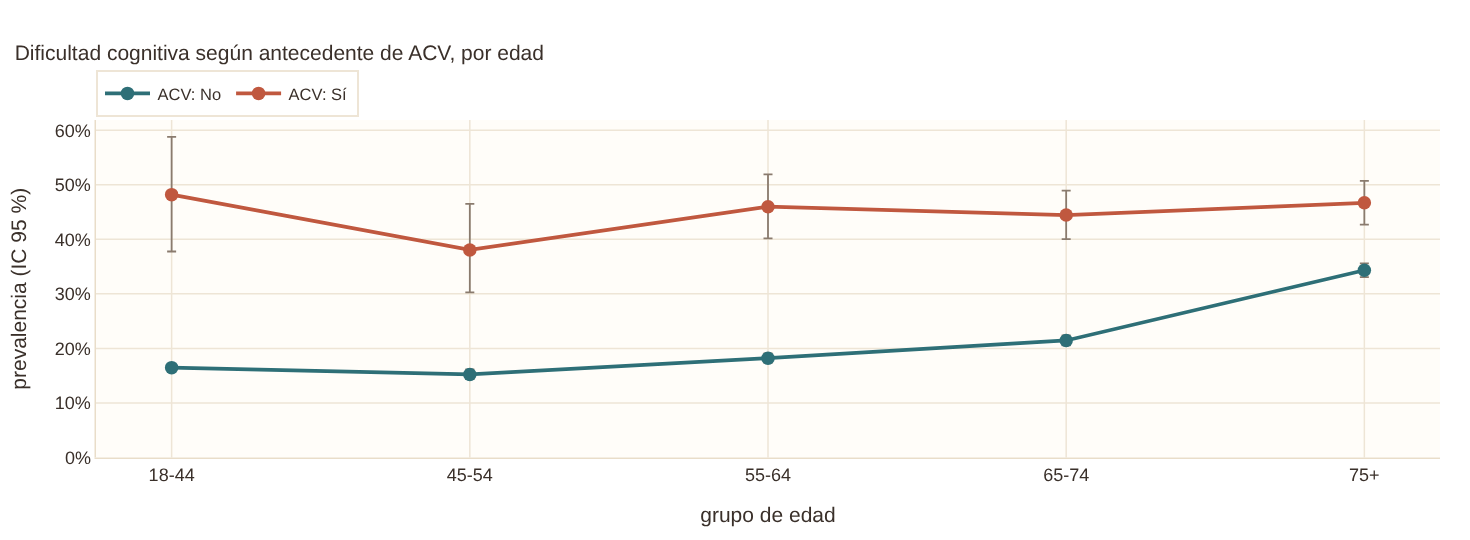

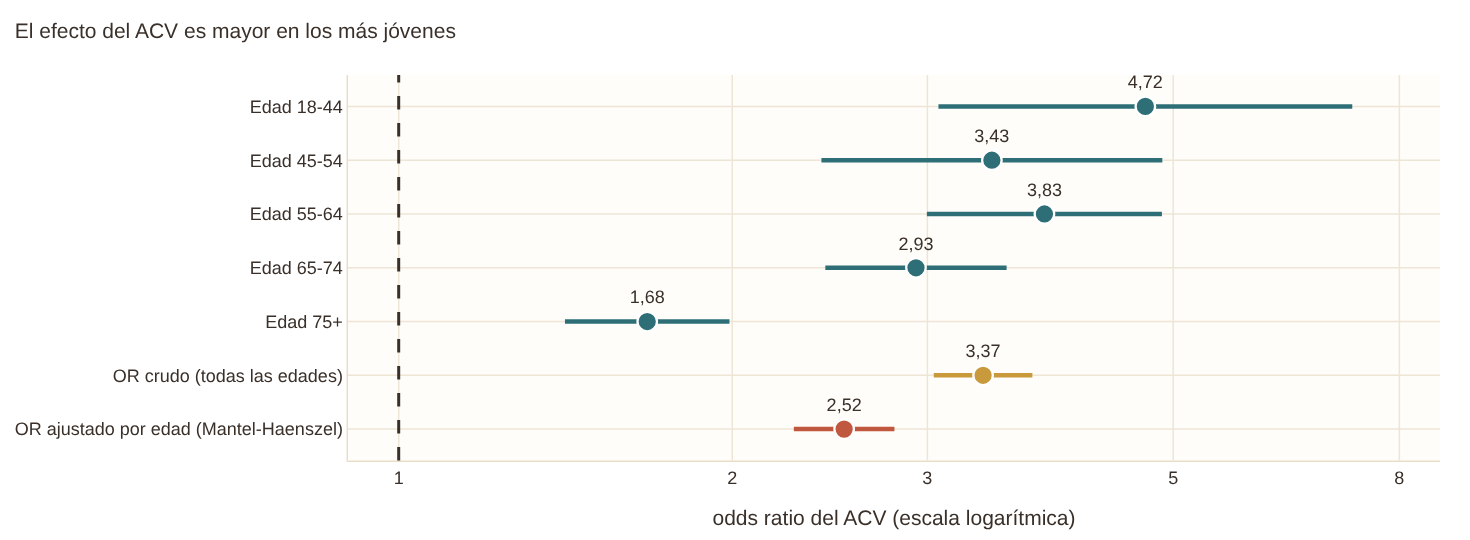

grupo,OR,IC inf.,IC sup.,adultos con ACV
Edad 18-44,4.72,3.07,7.25,83
Edad 45-54,3.43,2.41,4.89,134
Edad 55-64,3.83,3.00,4.88,274
Edad 65-74,2.93,2.43,3.54,477
Edad 75+,1.68,1.41,1.99,591
OR crudo (todas las edades),3.37,3.04,3.73,1560
OR ajustado por edad (Mantel-Haenszel),2.52,2.27,2.80,1560


In [9]:
mostrar(F.fig_acv_edad(df))
mostrar(F.fig_or_acv(df))
ver(F.tabla_or_acv(df).rename(columns={"ic_inf": "IC inf.", "ic_sup": "IC sup.", "n_acv": "adultos con ACV"}), {"OR": "{:.2f}", "IC inf.": "{:.2f}", "IC sup.": "{:.2f}"})

El antecedente de ACV es la exposición que da nombre a la pregunta de investigación, y por eso la pestaña le dedica dos
gráficas. En la primera, los adultos con ACV tienen una prevalencia de dificultad cognitiva del 45,3 % frente al 19,7 %
de quienes no lo tuvieron. Pero el ACV es mucho más frecuente en los mayores: hay 591 casos en mayores de 75 años y 83
en menores de 45. Como la edad también eleva por sí sola la dificultad, la comparación cruda mezcla dos efectos.

La segunda gráfica los separa. El OR crudo del ACV es 3,37 (IC 95 %: 3,04-3,73). Al ajustar por grupo de edad con el estimador de
Mantel-Haenszel baja a 2,52 (2,27-2,80), de modo que cerca de un tercio de la asociación cruda se explicaba por la edad y el
resto es un efecto propio del ACV. Lo que más llama la atención son los estratos: el OR es 4,72 en
menores de 45 años y baja de forma continua hasta 1,68 en mayores de 75. En los jóvenes el ACV multiplica la prevalencia de
16,5 % a 48,2 %; en los mayores, la base ya es alta (34,3 %) y el ACV la lleva a 46,7 %. Es decir que
la dificultad cognitiva tras un ACV es sobre todo un fenómeno relevante en las edades en que un ACV es raro, y la
diferencia entre estratos sugiere una interacción entre ACV y edad. Con el filtro de edad se puede explorar
cada tramo por separado.

Un detalle de lectura: en el panel, si se filtra por «ACV: Sí» o «ACV: No», la segunda gráfica avisa de que no hay suficientes
adultos con ACV, porque necesita ambos grupos para calcular el odds ratio.

## 2.5 Relaciones entre variables y estructura de los datos

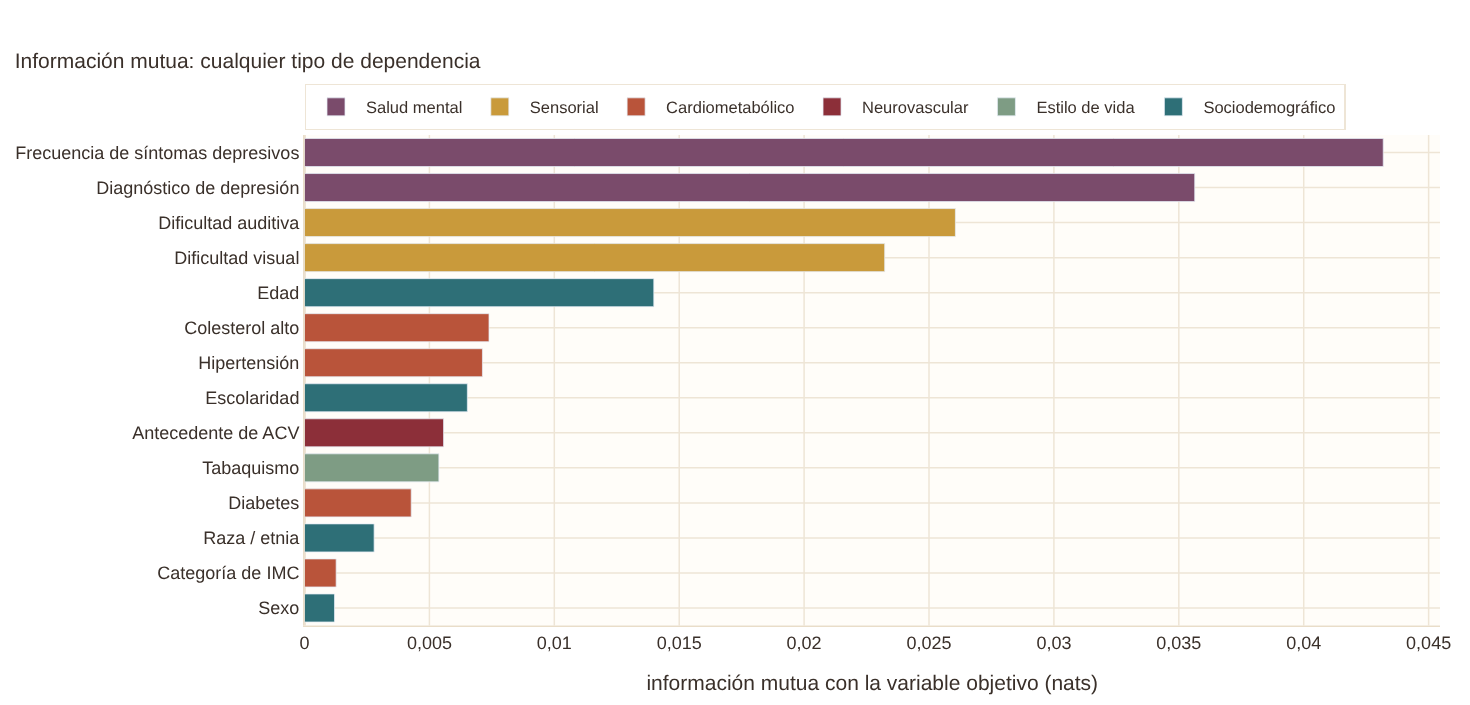

frecuencia_depresion    0.0432
depresion_dx            0.0356
dificultad_auditiva     0.0261
dificultad_visual       0.0232
edad                    0.0140
colesterol_alto         0.0074
hipertension            0.0071
educacion               0.0065
acv                     0.0056
tabaquismo              0.0054
diabetes                0.0043
raza_etnia              0.0028
imc_categoria           0.0013
sexo                    0.0012


In [10]:
mostrar(F.fig_info_mutua(A))
print(A["mi"].sort_values(ascending=False).round(4).to_string())

La información mutua mide cuánto reduce el conocimiento de una variable la incertidumbre sobre el objetivo, sin
suponer que la relación es lineal. Ordena los factores casi igual que la V de Cramér: la frecuencia de síntomas depresivos
(0,043 nats), el diagnóstico de depresión (0,036), la dificultad auditiva (0,026) y la visual (0,023). La diferencia
está en la edad, que sube al quinto lugar (0,014): su correlación lineal con el objetivo es débil (r biserial de 0,17), pero la
información mutua sí detecta la forma de U. Todos los valores son bajos, menores de 0,05, lo que confirma que ninguna variable
determina por sí sola el resultado y que el desempeño dependerá de combinar señales.

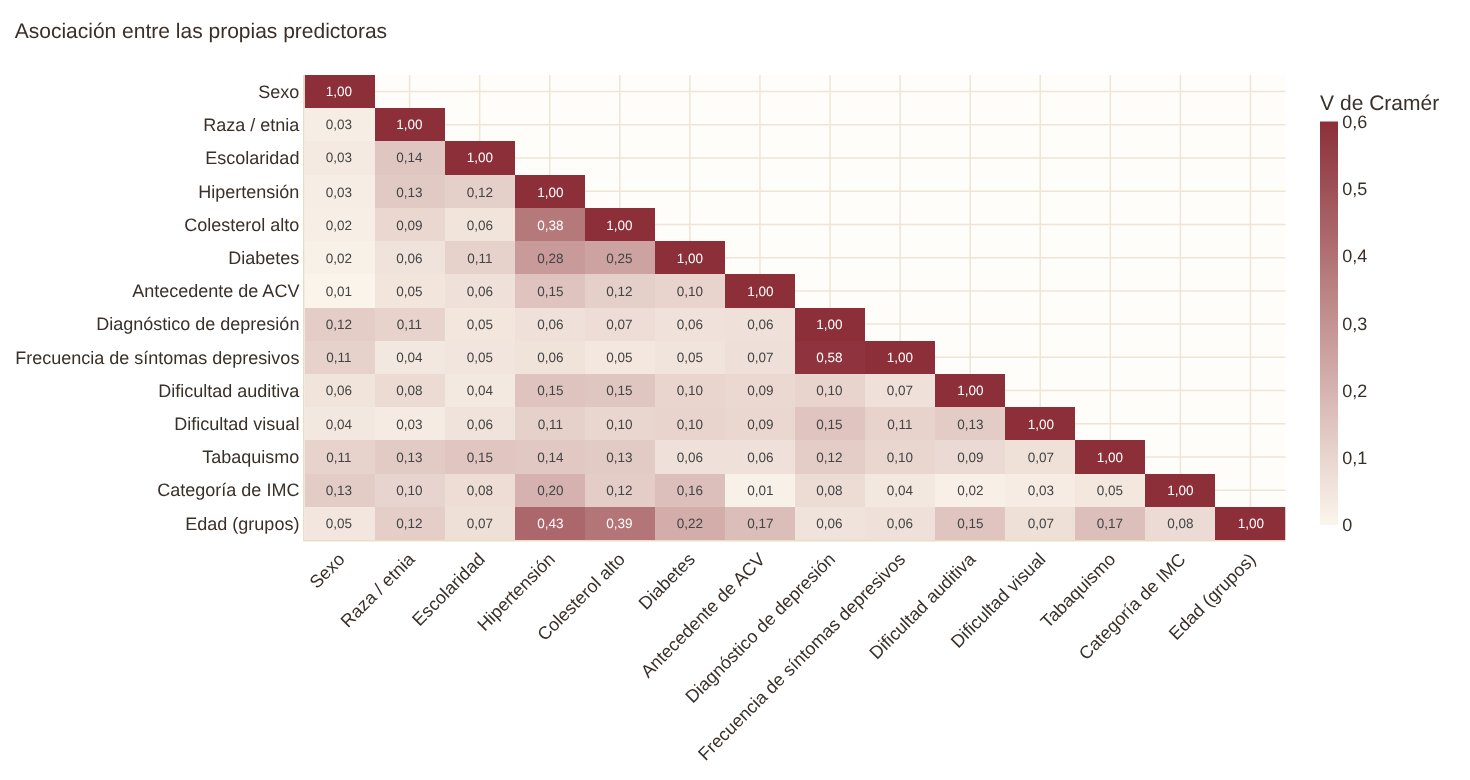

depresion_dx     frecuencia_depresion    0.584
hipertension     edad                    0.431
colesterol_alto  edad                    0.389
hipertension     colesterol_alto         0.377
                 diabetes                0.277
colesterol_alto  diabetes                0.250


In [11]:
mostrar(F.fig_cramer_heatmap(A))
c = A["cramer"].where(np.triu(np.ones(A["cramer"].shape, dtype=bool), 1)).stack().sort_values(ascending=False).head(6)
print(c.round(3).to_string())

El mapa de asociación entre predictoras responde a otra pregunta: si algunas variables dicen lo mismo. La pareja más
asociada es el diagnóstico de depresión con la frecuencia de síntomas (V = 0,58), algo natural porque miden el mismo
fenómeno por vías distintas, el historial diagnóstico y el estado actual. Después vienen hipertensión con edad (0,43),
colesterol con edad (0,39) e hipertensión con colesterol (0,38), el conocido agrupamiento cardiometabólico que crece con los
años. Nada supera 0,6, y por eso se mantienen las dos variables de depresión. Más abajo comprobamos con los VIF que no hay
una multicolinealidad que afecte al modelo.

Varianza explicada por las 5 primeras componentes: [0.097 0.07  0.06  0.057 0.054] | acumulada en 2: 0.167 | en 5: 0.337
Componentes para el 80 %: 16 de 28


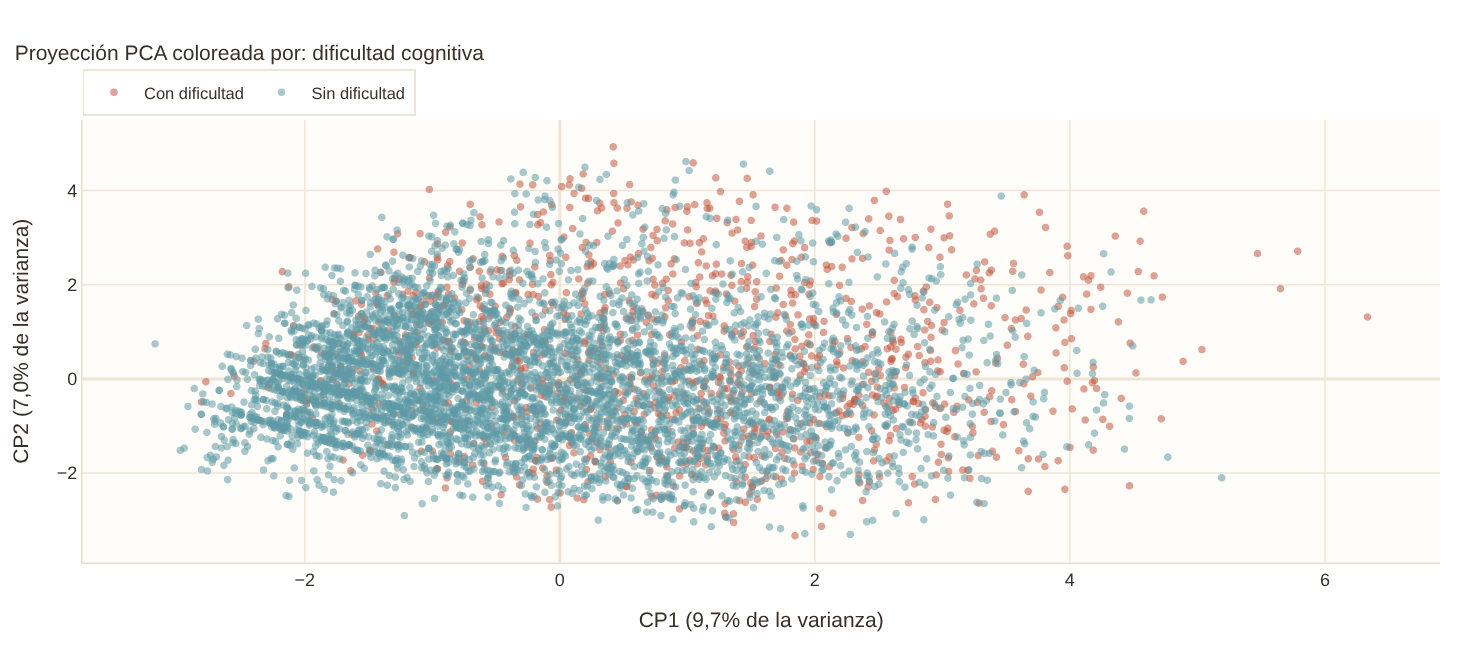

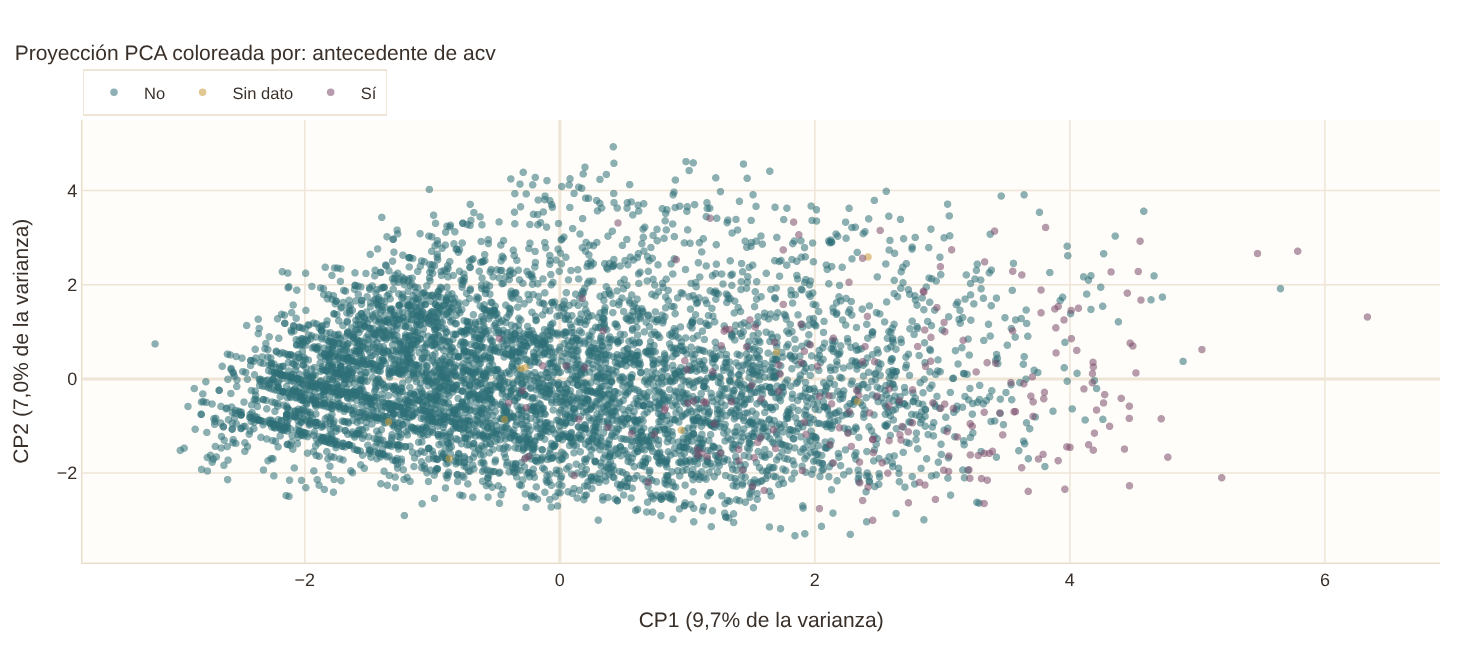

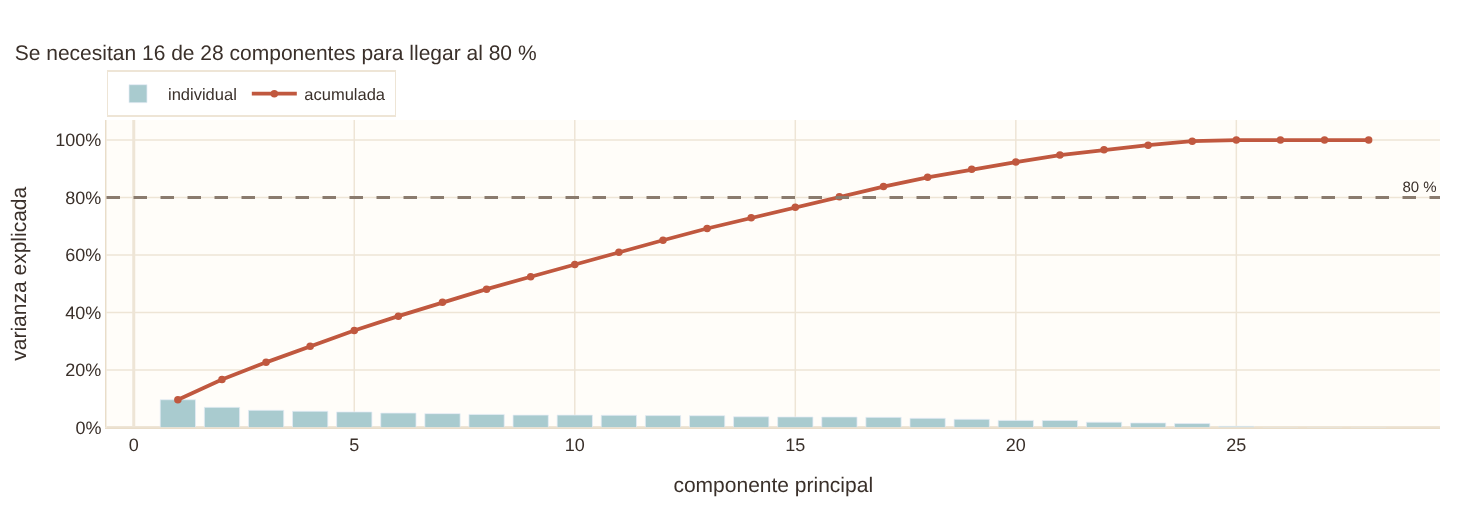

CP1 {'hipertension_Sí': 0.45, 'edad': 0.42, 'colesterol_alto_Sí': 0.4, 'diabetes_Sí': 0.32, 'dificultad_auditiva_Alguna': 0.25, 'acv_Sí': 0.21}
CP2 {'depresion_dx_Sí': 0.41, 'imc_categoria_Sobrepeso': -0.34, 'imc_categoria_Obesidad': 0.34, 'edad': -0.31, 'frecuencia_depresion_Diaria': 0.26, 'frecuencia_depresion_Semanal': 0.25}
CP3 {'imc_categoria_Obesidad': 0.49, 'imc_categoria_Sobrepeso': -0.43, 'depresion_dx_Sí': -0.42, 'frecuencia_depresion_Semanal': -0.26, 'frecuencia_depresion_Diaria': -0.24, 'educacion_Secundaria o GED': 0.22}


In [12]:
p = A["pca"]
print("Varianza explicada por las 5 primeras componentes:", np.round(p["varianza"][:5], 3), "| acumulada en 2:", round(p["acum"][1], 3), "| en 5:", round(p["acum"][4], 3))
print(f"Componentes para el 80 %: {p['k80']} de {len(p['varianza'])}")
mostrar(F.fig_pca(A, p["puntos"], "Dificultad cognitiva"))
mostrar(F.fig_pca(A, p["puntos"], "Antecedente de ACV"))
mostrar(F.fig_scree(A))
for cp in ["CP1", "CP2", "CP3"]:
    cc = p["cargas"][cp]; print(cp, cc.reindex(cc.abs().sort_values(ascending=False).index)[:6].round(2).to_dict())

El análisis de componentes principales resume las 28 columnas codificadas en pocas dimensiones para ver si
hay estructura. La varianza queda muy repartida: la primera componente explica solo el 9,7 %, las dos primeras el 16,7 % y se necesitan 16
de las 28 para llegar al 80 %. Esto indica que las predictoras aportan información poco redundante, coherente con los VIF bajos, y
que reducir la dimensión no traería ventaja.

Las componentes se pueden interpretar por sus cargas. La primera reúne hipertensión, edad, colesterol, diabetes, dificultad auditiva y ACV: es un eje de
envejecimiento y riesgo cardiometabólico. La segunda se define por el diagnóstico de depresión y los síntomas, con la edad en sentido
opuesto, porque los síntomas depresivos son más frecuentes en los adultos jóvenes. La tercera tiene que ver sobre todo con el peso corporal.

En el diagrama de dispersión, los adultos con dificultad (rojo) se desplazan hacia valores altos de la primera componente,
pero se solapan ampliamente con los demás; no hay una frontera lineal evidente. Es una advertencia temprana de que el desempeño será moderado. El selector
«Colorear por» permite pintar los mismos puntos por antecedente de ACV, depresión, año, edad o grupo, y los filtros
laterales también actúan sobre este gráfico, que muestra una muestra de 6.000 adultos. Al colorear por
ACV se ve que los adultos con ACV se concentran a la derecha, en la zona del eje cardiometabólico.

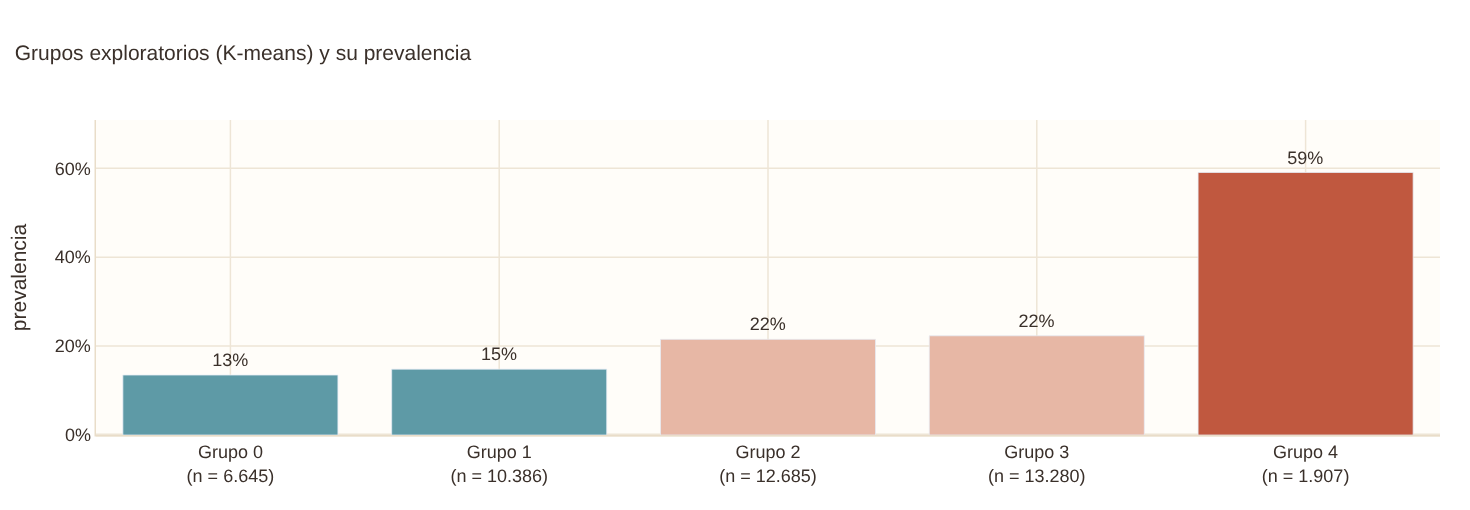

grupo,n,prevalencia,edad media,hipertension,con depresión,mujeres,fumador actual,acv
0,"6,645",13.5%,53.8,31%,16%,56%,3%,2%
1,"10,386",14.8%,49.8,29%,15%,53%,5%,2%
2,"12,685",21.5%,53.7,40%,15%,52%,18%,4%
3,"13,280",22.3%,54.1,42%,19%,57%,11%,4%
4,"1,907",59.0%,52.5,49%,80%,61%,25%,9%


Silueta por k: {2: 0.101, 3: 0.091, 4: 0.132, 5: 0.147, 6: 0.139} -> k elegido: 5


In [13]:
mostrar(F.fig_clusters(A))
ver(A["pca"]["perfil_clusters"].rename(columns={"cluster": "grupo", "edad_media": "edad media", "depresion_dx": "con depresión", "fumador_actual": "fumador actual"}),
    {"n": "{:,.0f}", "prevalencia": "{:.1%}", "edad media": "{:.1f}", "hipertension": "{:.0%}", "con depresión": "{:.0%}", "mujeres": "{:.0%}", "fumador actual": "{:.0%}", "acv": "{:.0%}"})
print("Silueta por k:", {k: round(v, 3) for k, v in A["pca"]["silueta"].items()}, "-> k elegido:", A["pca"]["k_opt"])

El agrupamiento con K-means sobre las componentes que explican el 80 % de la varianza es solo descriptivo. El coeficiente de silueta es bajo
en todos los valores de k que se evaluaron (entre 0,09 y 0,15), y eso quiere decir que los adultos no forman grupos bien separados, sino un
continuo de perfiles. Se reporta la solución de k = 5, la de mayor silueta, con esa advertencia.

Aun así, los perfiles son informativos. Hay un grupo pequeño, de 1.907 adultos, donde el 80 % tiene diagnóstico de depresión, uno
de cada cuatro fuma y la prevalencia de dificultad cognitiva es del 59 %, casi tres veces la global. Dos grupos más grandes (12.685 y
13.280 adultos) tienen prevalencias de 21,5 % y 22,3 %, con más hipertensión, más tabaquismo y más ACV. Los otros dos grupos, de adultos más jóvenes y con
menos carga de enfermedad, tienen prevalencias de 13,5 % y 14,8 %. Hay al menos dos rutas distintas hacia la dificultad cognitiva
subjetiva, una afectiva y otra vascular y de envejecimiento. Un modelo lineal aditivo las captura solo en parte, y
los modelos no lineales de las siguientes entregas podrían aprovecharlas mejor.

## 2.6 Calidad de los datos y auditoría de fuga

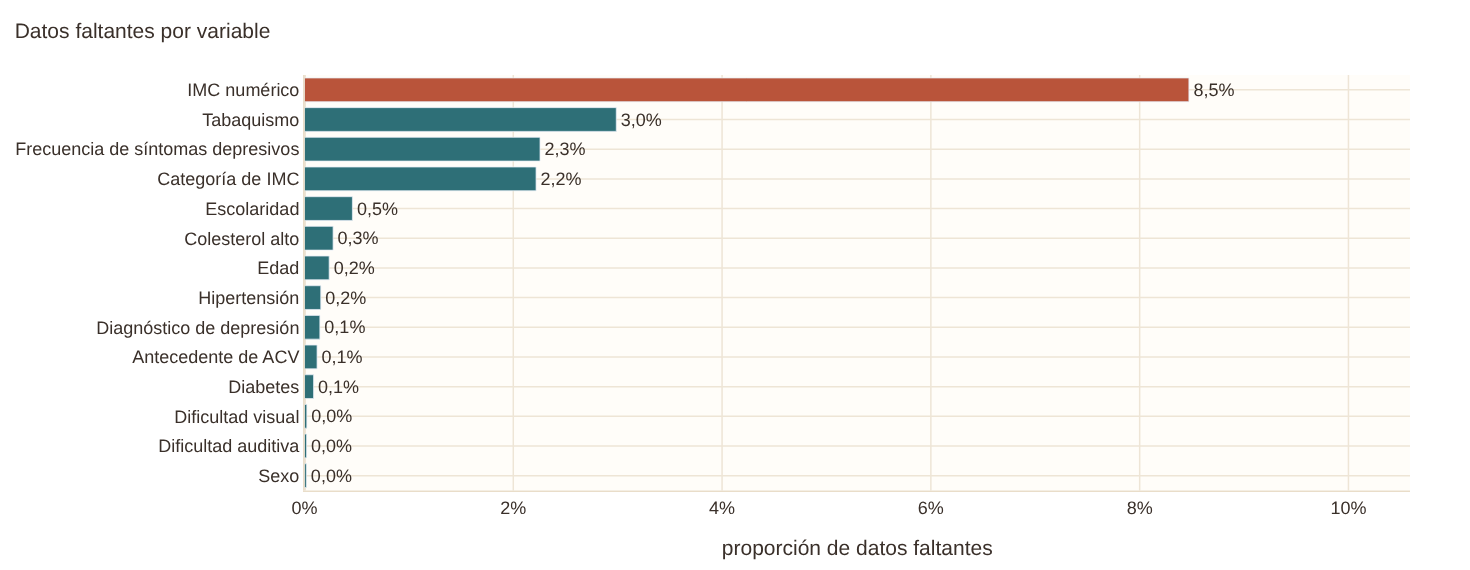

Filas con al menos un faltante en las predictoras: 6.18%


In [14]:
mostrar(F.fig_faltantes(df))
print(f"Filas con al menos un faltante en las predictoras: {df[PREDICTORAS].isna().any(axis=1).mean():.2%}")

Los datos faltantes son escasos. Ninguna predictora supera el 3 %: tabaquismo (3,0 %), frecuencia de depresión
(2,3 %) y categoría de IMC (2,2 %) son las más afectadas, y solo el 6,2 % de las filas tiene algún faltante en las predictoras. El
valor que se sale de la escala es el IMC numérico, con 8,5 %, casi cuatro veces el de su categoría. La razón no es azarosa: el NCHS
reemplaza el peso o la talla por un código de supresión cuando el valor es excepcionalmente alto o bajo, de modo que el dato falta justo
por ser extremo. Entre quienes tienen el dato suprimido el 57,9 % tiene obesidad, frente a 31,5 % entre quienes lo tienen publicado
(la categoría de IMC se calculó antes de la supresión y por eso lo permite comprobar). Si se hubiera usado el IMC numérico imputado con la
mediana, se habrían borrado los casos extremos. Por eso el modelo usa la categoría y no el valor numérico.

Con el panel de filtros se puede ver cómo cambian los faltantes entre subgrupos. Por ejemplo, entre las mujeres el faltante de la categoría de IMC es
bastante mayor que entre los hombres, lo que coincide con lo que se reporta en la literatura sobre la no respuesta al peso en las encuestas de salud.

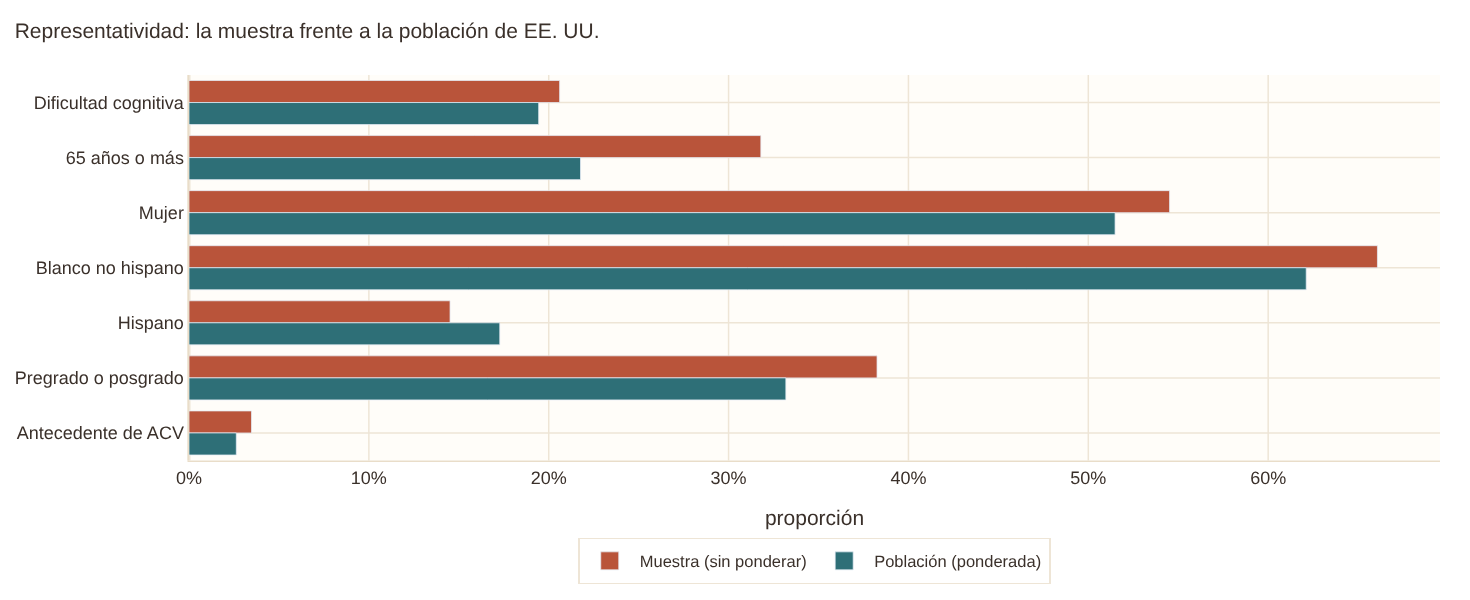

indicador,Muestra sin ponderar,Población ponderada (EE. UU.),diferencia (pp)
Dificultad cognitiva,20.6%,19.4%,+1.2
65 años o más,31.8%,21.8%,+10.0
Mujer,54.5%,51.5%,+3.0
Blanco no hispano,66.1%,62.1%,+4.0
Hispano,14.5%,17.3%,-2.8
Pregrado o posgrado,38.3%,33.2%,+5.1
Antecedente de ACV,3.5%,2.6%,+0.8


In [15]:
mostrar(F.fig_sesgo(A))
ver(A["sesgo"].rename(columns={"diferencia_pp": "diferencia (pp)"}), {"Muestra sin ponderar": "{:.1%}", "Población ponderada (EE. UU.)": "{:.1%}", "diferencia (pp)": "{:+.1f}"})

La NHIS tiene un diseño muestral complejo y cada adulto trae un peso que indica a cuántas personas de la población representa. Comparar las
proporciones sin ponderar, que es lo que ve el modelo, con las ponderadas, que describen a Estados Unidos, da una idea de hacia dónde está
sesgada la muestra. Los adultos de 65 años o más son el 31,8 % de la muestra pero el 21,8 % de la población, una diferencia de 10 puntos. Las
personas con estudios universitarios están sobrerrepresentadas en 5,1 puntos, los blancos no hispanos en 4,0 y las mujeres en 3,0, mientras que
los hispanos están subrepresentados en 2,8. Como la dificultad cognitiva crece con la edad, la prevalencia en la muestra (20,6 %) queda
un poco por encima de la poblacional (19,4 %).

El modelo se entrena sin pesos porque su objetivo es discriminar entre personas y no estimar prevalencias del país. Pero sus probabilidades
reflejan la composición de la muestra, no la de la población estadounidense, y mucho menos la de otro país.

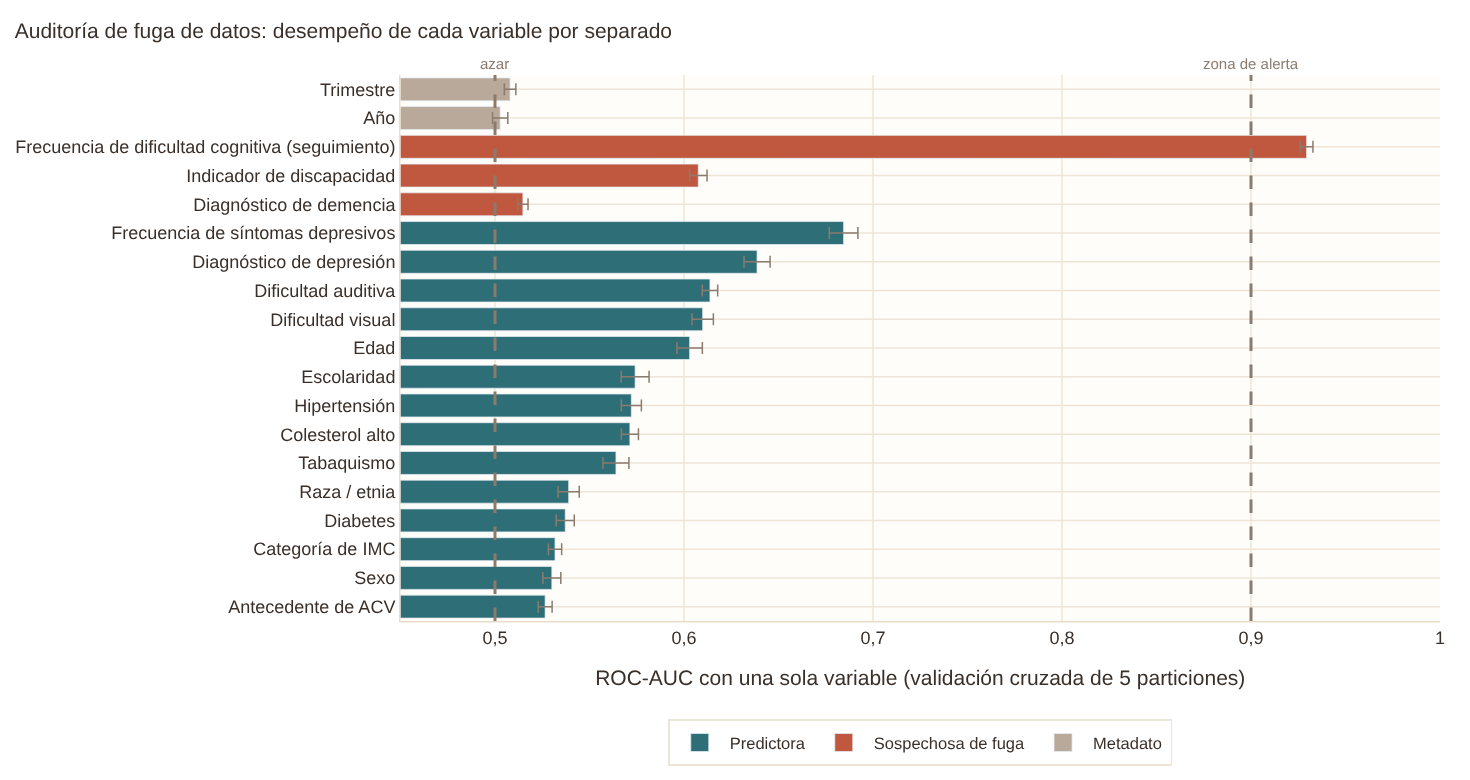

variable,ROC-AUC,desv. est.,grupo
Frecuencia de dificultad cognitiva (seguimiento),0.929,0.003,Sospechosa de fuga
Frecuencia de síntomas depresivos,0.684,0.008,Predictora
Diagnóstico de depresión,0.639,0.007,Predictora
Dificultad auditiva,0.614,0.004,Predictora
Dificultad visual,0.610,0.006,Predictora
Indicador de discapacidad,0.608,0.005,Sospechosa de fuga
Edad,0.603,0.007,Predictora
Escolaridad,0.574,0.007,Predictora
Hipertensión,0.572,0.005,Predictora
Colesterol alto,0.571,0.005,Predictora


In [16]:
mostrar(F.fig_auditoria_fuga(A))
ver(A["auc_uni"].sort_values("auc", ascending=False).assign(variable=lambda t: t["variable"].map(lambda v: ETIQUETAS.get(v, v)))
    .rename(columns={"auc": "ROC-AUC", "de": "desv. est.", "grupo": "grupo"}), {"ROC-AUC": "{:.3f}", "desv. est.": "{:.3f}"})

La auditoría de fuga entrena una regresión logística con cada variable por separado y mide su ROC-AUC con validación cruzada. Un factor
de riesgo legítimo de un fenómeno multifactorial no debería, por sí solo, acercarse a la zona de alerta de 0,9. Las 14 predictoras están entre 0,527
(ACV) y 0,684 (frecuencia de síntomas depresivos). El ACV tiene el AUC más bajo a pesar de ser un factor fuerte porque afecta solo al 3,5 % de los adultos:
identifica bien a esos pocos pero no discrimina en los demás. Los metadatos de año y trimestre quedan en 0,50, sin información sobre el objetivo.

La pregunta de seguimiento sobre la frecuencia de la dificultad alcanza 0,929, algo imposible para un factor de riesgo, y la razón es que
no predice el objetivo sino que lo contiene: su categoría «no aplica» equivale a haber respondido que no. La auditoría también enseña que los
números no bastan. El indicador de discapacidad tiene un AUC de solo 0,608, que no dispararía ninguna alarma, y aun así se construye con la propia
pregunta objetivo; el diagnóstico de demencia tiene 0,515 porque es raro (0,8 %), pero conceptualmente es un proxy del resultado. Las tres variables se
descartan. Quedan «en observación» la frecuencia de síntomas depresivos, porque la depresión puede alterar la concentración y parte de su efecto sería solapamiento de síntomas, y las dificultades
auditiva y visual, que usan la misma escala de respuesta del Washington Group que el objetivo y podrían inflar la correlación por estilo de respuesta.

## 2.7 Detalles que el dashboard no muestra

### Pruebas estadísticas detrás de las gráficas

In [17]:
# Edad frente al objetivo (Mann-Whitney) y asociación de la edad con las demás predictoras (Kruskal-Wallis)
a, b = df.loc[y == 1, "edad"].dropna(), df.loc[y == 0, "edad"].dropna()
u = stats.mannwhitneyu(a, b)
print(f"Edad con dificultad: mediana {a.median():.0f}; sin dificultad: {b.median():.0f}; r biserial por rangos = {2 * u.statistic / (len(a) * len(b)) - 1:.3f}")

filas = []
for v in PREDICTORAS_CAT:
    sub = df[[v, "edad"]].dropna()
    grupos = [g["edad"].values for _, g in sub.groupby(v)]
    h, p_ = stats.kruskal(*grupos)
    filas.append([ETIQUETAS[v], max(0.0, (h - len(grupos) + 1) / (len(sub) - len(grupos)))])
ver(pd.DataFrame(filas, columns=["variable", "ε² con la edad"]).sort_values("ε² con la edad", ascending=False).head(6), {"ε² con la edad": "{:.3f}"})

Edad con dificultad: mediana 61; sin dificultad: 52; r biserial por rangos = 0.174


variable,ε² con la edad
Hipertensión,0.193
Colesterol alto,0.153
Dificultad auditiva,0.064
Raza / etnia,0.057
Diabetes,0.048
Tabaquismo,0.045


Quienes reportan dificultad son mayores, con una mediana de 61 años frente a 52, pero el efecto lineal es pequeño (r biserial de 0,17); la
forma de U que vimos antes es la que explica por qué. La edad, en cambio, está fuertemente ligada a algunas predictoras: la
hipertensión (ε² = 0,19) y el colesterol alto (0,15) se concentran en los adultos mayores, con una diferencia mediana de unos 20 años, y la dificultad
auditiva también (0,06). Eso anticipa un problema de confusión por edad: parte de la asociación cruda de esos factores con el objetivo es simplemente que marcan
mayor edad, y el modelo tendrá que ajustar por ella. Es lo que pasa con la hipertensión, que en el capítulo 3 deja de ser significativa.

In [18]:
# Multicolinealidad: factor de inflación de la varianza (VIF) con la codificación del modelo
from statsmodels.stats.outliers_influence import variance_inflation_factor
completos = TRAIN[PREDICTORAS].dropna()
X = completos[PREDICTORAS_CAT].copy()
for v in PREDICTORAS_CAT:
    X[v] = pd.Categorical(X[v], categories=A["categorias"][v])
X = pd.get_dummies(X, drop_first=True, dtype=float)
X["edad"] = completos["edad"]; X.insert(0, "const", 1.0)
vif = pd.Series([variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])], index=X.columns[1:]).sort_values(ascending=False)
print(vif.head(6).round(2).to_string()); print("VIF máximo:", round(vif.max(), 2), "| columnas con VIF > 5:", int((vif > 5).sum()))

/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


...

/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


educacion_Técnico o universidad incompleta    3.37
educacion_Pregrado                            3.27
educacion_Secundaria o GED                    3.15
educacion_Posgrado                            2.68
edad                                          1.58
depresion_dx_Sí                               1.57
VIF máximo: 3.37 | columnas con VIF > 5: 0


/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


El VIF más alto es 3,4, en las categorías de escolaridad, que son mutuamente excluyentes por construcción, y ninguna columna supera 5. No hay multicolinealidad
problemática, así que se pueden conservar las dos variables de depresión y los coeficientes del modelo se interpretan sin cautelas especiales por este motivo.

In [19]:
# ¿Los registros incompletos se parecen a los completos? ¿De qué depende el faltante?
inc = TRAIN[PREDICTORAS].isna().any(axis=1)
comp = pd.DataFrame({"completos": [TRAIN.loc[~inc, OBJETIVO].mean(), TRAIN.loc[~inc, "edad"].median(), (TRAIN.loc[~inc, "sexo"] == "Mujer").mean()],
                     "incompletos": [TRAIN.loc[inc, OBJETIVO].mean(), TRAIN.loc[inc, "edad"].median(), (TRAIN.loc[inc, "sexo"] == "Mujer").mean()]},
                    index=["prevalencia de dificultad", "edad mediana", "proporción de mujeres"])
ver(comp.reset_index().rename(columns={"index": ""}), {"completos": "{:.3f}", "incompletos": "{:.3f}"})
import statsmodels.formula.api as smf
t = TRAIN.assign(edad10=TRAIN["edad"] / 10, mujer=(TRAIN["sexo"] == "Mujer").astype(int), f_imc=TRAIN["imc_categoria"].isna().astype(int)).dropna(subset=["edad", "mujer"])
m = smf.logit("f_imc ~ edad10 + mujer + dificultad_cognitiva + C(anio)", data=t).fit(disp=0)
print(np.exp(m.params).round(2).to_string())

,completos,incompletos
prevalencia de dificultad,0.207,0.197
edad mediana,54.000,55.000
proporción de mujeres,0.540,0.630


Intercept               0.01
C(anio)[T.2023]         0.96
edad10                  1.04
mujer                   4.39
dificultad_cognitiva    0.71


Los registros incompletos son casi iguales a los completos en la variable objetivo (19,7 % frente a 20,7 %, V de Cramér de 0,003) y en la edad, pero
no en el sexo: el 63 % de los registros incompletos son mujeres, frente al 54 % de los completos. Modelar la probabilidad de que falte la categoría de IMC
da un odds ratio de 4,4 para las mujeres, lo que confirma que el faltante no es completamente aleatorio. Se clasifica como MAR, dependiente de variables
observadas, con un posible componente MNAR para el peso. En la práctica esto se traduce en una imputación sencilla (la moda dentro del pipeline) más un
indicador de faltante para las tres variables con más del 2 %: frecuencia de depresión, tabaquismo y categoría de IMC.

In [20]:
# Duplicados, perfiles repetidos y valores atípicos
print("Hogares repetidos dentro de un año:", TRAIN.duplicated(["anio", "id_hogar"]).sum())
print(f"Filas con el mismo perfil de predictoras que otra: {TRAIN.duplicated(PREDICTORAS).mean():.1%}")
g = TRAIN.groupby(PREDICTORAS, dropna=False)[OBJETIVO].agg(["size", "mean"])
print("Perfiles repetidos con ambas clases:", int(((g['size'] > 1) & g['mean'].between(0.01, 0.99)).sum()))
x = TRAIN["imc"].dropna(); q1, q3 = x.quantile([.25, .75]); lim = q3 + 1.5 * (q3 - q1)
print(f"IMC: {(x > lim).mean():.2%} por encima de {lim:.1f} kg/m² (valores plausibles de obesidad severa)")

Hogares repetidos dentro de un año: 0
Filas con el mismo perfil de predictoras que otra: 16.3%
Perfiles repetidos con ambas clases: 879
IMC: 1.55% por encima de 42.2 kg/m² (valores plausibles de obesidad severa)


No hay hogares repetidos ni filas idénticas, pero el 16,3 % de los adultos comparte con otro exactamente la misma combinación de predictoras. Es esperable con trece
variables categóricas de pocos niveles. Además, 879 de esos perfiles repetidos incluyen personas de ambas clases: con estas variables hay adultos
indistinguibles entre sí aunque uno reporte dificultad y el otro no, y esto impone un techo al desempeño alcanzable. Tampoco eliminamos valores atípicos. El 1,6 %
del IMC por encima de 42 kg/m² corresponde a obesidad severa, plausible, y un análisis multivariado con Isolation Forest en el Entregable 1 mostró que el 1 % más atípico
tiene más ACV, más pérdida visual y una prevalencia de dificultad del 76 %: son las personas con más carga de enfermedad, justamente las más relevantes para la pregunta.
Retirarlas sesgaría el modelo hacia la población más sana.